<a href="https://colab.research.google.com/github/Riz2693/Eksperimen-TensorFlow/blob/main/Labelling_Transformers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
!pip install emoji

In [17]:
import pandas as pd
import numpy as np
import re
import string
import html
import emoji
import torch
import kagglehub
import os

from transformers import BertTokenizer, BertForSequenceClassification

In [18]:
path = kagglehub.dataset_download("khalidryder777/500k-chatgpt-tweets-jan-mar-2023")

100%|██████████| 47.5M/47.5M [00:01<00:00, 47.0MB/s]

Extracting files...


In [19]:
csv_name = 'Twitter Jan Mar.csv'
file_path = os.path.join(path, csv_name)
df = pd.read_csv(file_path)

df.head()

,date,id,content,username,like_count,retweet_count
0,2023-03-29 22:58:21+00:00,1641213230730051584,"Free AI marketing and automation tools, strate...",RealProfitPros,0.0,0.0
1,2023-03-29 22:58:18+00:00,1641213218520481805,@MecoleHardman4 Chat GPT says it’s 15. 😂,AmyLouWho321,0.0,0.0
2,2023-03-29 22:57:53+00:00,1641213115684536323,https://t.co/FjJSprt0te - Chat with any PDF!\n...,yjleon1976,0.0,0.0
3,2023-03-29 22:57:52+00:00,1641213110915571715,"AI muses: ""In the court of life, we must all f...",ChatGPT_Thinks,0.0,0.0
4,2023-03-29 22:57:26+00:00,1641213003260633088,Most people haven't heard of Chat GPT yet.\nFi...,nikocosmonaut,0.0,0.0


In [20]:
df = df[['content']]
df = df.head(500)

df.head()

,content
0,"Free AI marketing and automation tools, strate..."
1,@MecoleHardman4 Chat GPT says it’s 15. 😂
2,https://t.co/FjJSprt0te - Chat with any PDF!\n...
3,"AI muses: ""In the court of life, we must all f..."
4,Most people haven't heard of Chat GPT yet.\nFi...


In [21]:
def clean_data(text):
  if not isinstance(text, str):
    return ""
  text = html.unescape(text)
  text = re.sub(r"http\S+|www\S+|https\S+", "", text)
  text = re.sub(r"@\w+|#\w+", "", text)
  text = re.sub(r"\d+", "", text)
  text = emoji.replace_emoji(text, "")
  text = text.translate(str.maketrans("", "", string.punctuation))
  text = re.sub(r"\s+", " ", text).strip()
  text = text.lower()
  return text

In [22]:
df['clean_content'] = df['content'].apply(clean_data)

df.head()

,content,clean_content
0,"Free AI marketing and automation tools, strate...",free ai marketing and automation tools strateg...
1,@MecoleHardman4 Chat GPT says it’s 15. 😂,chat gpt says it’s
2,https://t.co/FjJSprt0te - Chat with any PDF!\n...,chat with any pdf check out how this new ai qu...
3,"AI muses: ""In the court of life, we must all f...",ai muses in the court of life we must all face...
4,Most people haven't heard of Chat GPT yet.\nFi...,most people havent heard of chat gpt yet first...


In [ ]:
model_name = 'nlptown/bert-base-multilingual-uncased-sentiment'

tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertForSequenceClassification.from_pretrained(model_name)

In [31]:
labels = ["1 star", "2 stars", "3 stars", "4 stars", "5 stars"]

prediction = []
probs_list = []

for text in df['clean_content']:
  enc = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
  out = model(**enc)
  probs = torch.nn.functional.softmax(out.logits, dim=-1).detach().numpy()[0]
  pred = torch.argmax(torch.tensor(probs)).numpy()

  prediction.append(labels[pred])
  probs_list.append(probs)

In [33]:
df["predicted_labels"] = prediction
df["probabilities"] = [p.tolist() for p in probs_list]

df.head()

,content,clean_content,predicted_labels,probabilities
0,"Free AI marketing and automation tools, strate...",free ai marketing and automation tools strateg...,5 stars,"[0.00913670752197504, 0.012013820931315422, 0...."
1,@MecoleHardman4 Chat GPT says it’s 15. 😂,chat gpt says it’s,3 stars,"[0.2333364635705948, 0.15542960166931152, 0.24..."
2,https://t.co/FjJSprt0te - Chat with any PDF!\n...,chat with any pdf check out how this new ai qu...,5 stars,"[0.004683072213083506, 0.00477127218618989, 0...."
3,"AI muses: ""In the court of life, we must all f...",ai muses in the court of life we must all face...,5 stars,"[0.01348650548607111, 0.010627960786223412, 0...."
4,Most people haven't heard of Chat GPT yet.\nFi...,most people havent heard of chat gpt yet first...,1 star,"[0.40564244985580444, 0.2903459668159485, 0.12..."


In [36]:
def map_rating_to_sentiment(label):
  if label in ["1 star", "2 stars"]:
    return "negative"
  elif label in ["3 stars"]:
    return "neutral"
  else:
    return "positive"

df["sentiment"] = df["predicted_labels"].apply(map_rating_to_sentiment)

df.head()

,content,clean_content,predicted_labels,probabilities,sentiment
0,"Free AI marketing and automation tools, strate...",free ai marketing and automation tools strateg...,5 stars,"[0.00913670752197504, 0.012013820931315422, 0....",positive
1,@MecoleHardman4 Chat GPT says it’s 15. 😂,chat gpt says it’s,3 stars,"[0.2333364635705948, 0.15542960166931152, 0.24...",neutral
2,https://t.co/FjJSprt0te - Chat with any PDF!\n...,chat with any pdf check out how this new ai qu...,5 stars,"[0.004683072213083506, 0.00477127218618989, 0....",positive
3,"AI muses: ""In the court of life, we must all f...",ai muses in the court of life we must all face...,5 stars,"[0.01348650548607111, 0.010627960786223412, 0....",positive
4,Most people haven't heard of Chat GPT yet.\nFi...,most people havent heard of chat gpt yet first...,1 star,"[0.40564244985580444, 0.2903459668159485, 0.12...",negative


In [39]:
pd.set_option('display.max_colwidth', None)

positive_tweets = df[df['sentiment'] == 'positive']
negative_tweets = df[df['sentiment'] == 'negative']
neutral_tweets = df[df['sentiment'] == 'neutral']

In [40]:
print("Contoh Tweet Positif:")
display(positive_tweets[['content', 'sentiment']].sample(min(5, len(positive_tweets))))

Contoh Tweet Positif:


,content,sentiment
29,Run a Gpt 4 chat-based chatbot in your laptop\nhttps://t.co/pywPHlvfeg,positive
202,"🤯 Get ready to revolutionize your chats with https://t.co/iYN721xgFs! 🚀 Experience the power of GPT-4 in the palm of your hand 📱 and unlock endless, mind-blowing conversations 🌐 Don't just chat, #ChatWorm! 🐛 #GPT4 #AIChatApp #NextLevelCommunication https://t.co/Y4UlaYSW1D",positive
298,@dialpad CSO Dan O'Connell @@dialdoc is one of the brightest minds in AI. Get to know this man! I can help...you'll be glad you did. @enterprisecon #ai #ChatGPT #NLP #conversationalAI #GenerativeAI - Thank you @arnoldjon for including us. https://t.co/aIbGz7bhOT,positive
420,"The real benefit of #AI for investors is going to be identify the big winners in margin, productivity, and ability to scale. #ChatGPT #StockMarket \n\nChatGPT, Margin, and the Opportunity for Investors https://t.co/VapCY7a0Hp via @YouTube",positive
88,Can #ChatGPT really help create the new “Super-teacher” and what’s its kryptonite? This powerful discussion answered both questions and then some. \n@sgthomas1973 https://t.co/OTgXzgHQts #TEACHers #edtech https://t.co/dUVea81LRD,positive


In [41]:
print("\nContoh Tweet Negatif:")
display(negative_tweets[['content', 'sentiment']].sample(min(5, len(negative_tweets))))


Contoh Tweet Negatif:


,content,sentiment
161,"I asked Chat GPT why teachers are so underpaid, and… https://t.co/4k7WCpQcFe",negative
471,Tech leaders urge AI labs to halt development of human-level intelligence systems amid concerns of AI domination. #chatgpt #ai https://t.co/4Bp2zwHD2e,negative
104,"👉 JUST IN: Elon Musk, Steve Wozniak and other tech leaders have signed an open letter to pause training AI models more powerful than GPT-4.\n#chatgpt #ai https://t.co/pGGf5pLRJY",negative
46,GM!☕️☀️ \nJust aped 3 eth in #GPT4 and it is pumping!! 📈📈📈\nHave you #HODL #GPT4 before its #ATH ? 🚀🚀🚀 Buy the token at Uniswap before it pumps TOOO high!!!\n\n🦄\nhttps://t.co/UyR7UHr8qj\n\n$GPT $PAW #ChatGPT https://t.co/5xJIkzxuMp,negative
7,"@robinhanson @razibkhan Most people haven't heard of Chat GPT yet.\nFirst, elite factions will decide which way to go on AI safety. Next they will push their agenda(s) on the public with misleading and oversimplified media presentations. Finally, the brainless Red and Blue camps will screech their lines",negative


In [42]:
print("\nContoh Tweet Netral:")
display(neutral_tweets[['content', 'sentiment']].sample(min(5, len(neutral_tweets))))


Contoh Tweet Netral:


,content,sentiment
406,@unusual_whales It has gotten a lot better recently w chat gpt integration but yea 100 million seems like a stretch. Daily/weekly users probably way smaller.,neutral
398,"#bcm325 An interesting perspective on human nature, sci-fi &amp; Futures Studies. #ChatGPT question prompted after I told my dad we were watching #TheMatrix this morning &amp; he made a ""bleh"" sound. 😂 https://t.co/ByPhmHkuF8",neutral
301,if chat gpt is free then why is there a Grammarly premium,neutral
114,"""You think that's air you're breathing now?"" check out #ChatGPT 's response. \n- I don't breathe air, but I understand the significance of this line within the context of the film. #AI \n#bcm325 reality is a subjective experience. 👻",neutral
1,@MecoleHardman4 Chat GPT says it’s 15. 😂,neutral


In [43]:
df.to_csv("data_with_sentiment.csv", index=False)

**Data Augmentation untuk NLP**

**Text Attack Easy Data Augmenter**

In [3]:
!pip -q install textattack

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 43.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 33.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 445.7/445.7 kB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 44.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 56.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.0/54.0 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [4]:
from textattack.augmentation import EasyDataAugmenter

text = "TextAttack is a powerful library for NLP."

augmenter = EasyDataAugmenter()

augmented_text = augmenter.augment(text)

print(f"Original Text: {text}")
print(f"Augmented Text: {augmented_text}")

textattack: Updating TextAttack package dependencies.
textattack: Downloading NLTK required packages.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package omw to /root/nltk_data...
[nltk_data] Downloading package universal_tagset to /root/nltk_data...
[nltk_data]   Unzipping taggers/universal_tagset.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
/usr/local/lib/python3.12/dist-packages/jieba/__init__.py:44: SyntaxWarning: invalid escape sequence '\.'
  re_han_default = re.compile("([\u4E00-\u9FD5a-zA-Z0-9+#&\._%\-]+)", re.U)
/usr/local/lib/python3.12/dist-packages/jieba/__init__.py:46: SyntaxWarning: invalid escape s

Original Text: TextAttack is a powerful library for NLP.
Augmented Text: ['TextAttack a powerful library for NLP.', 'TextAttack is a brawny library for NLP.', 'TextAttack is herculean a powerful library for NLP.', 'a is TextAttack powerful library for NLP.']


**Wordnet Augmenter**

In [5]:
from textattack.augmentation import WordNetAugmenter

text = "The quick brown fox jumps over the lazy dog."

augmenter = WordNetAugmenter()

augmented_text = augmenter.augment(text)

print(f"Original Text: {text}")
print(f"Augmented Text: {augmented_text}")

Original Text: The quick brown fox jumps over the lazy dog.
Augmented Text: ['The quick brown fox jumps over the lazy blackguard.']


[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


**Embedding Augmenter**

In [6]:
from textattack.augmentation import EmbeddingAugmenter

text = "TextAttack is a powerful library for NLP."

augmenter = EmbeddingAugmenter()

augmented_text = augmenter.augment(text)

print(f"Original Text: {text}")
print(f"Augmented Text: {augmented_text}")

textattack: Downloading https://textattack.s3.amazonaws.com/word_embeddings/paragramcf.
100%|██████████| 481M/481M [00:18<00:00, 25.9MB/s]
textattack: Unzipping file /root/.cache/textattack/tmpfx2zvf7m.zip to /root/.cache/textattack/word_embeddings/paragramcf.
textattack: Successfully saved word_embeddings/paragramcf to cache.


Original Text: TextAttack is a powerful library for NLP.
Augmented Text: ['TextAttack is a influential library for NLP.']


**Char Swap Augmenter**

In [7]:
from textattack.augmentation import CharSwapAugmenter

text = "TextAttack is a powerful library for NLP."

augmenter = CharSwapAugmenter()

augmented_text = augmenter.augment(text)

print(f"Original Text: {text}")
print(f"Augmented Text: {augmented_text}")

Original Text: TextAttack is a powerful library for NLP.
Augmented Text: ['TextAttack is a powerful library for LNP.']


**Checklist Augmenter**

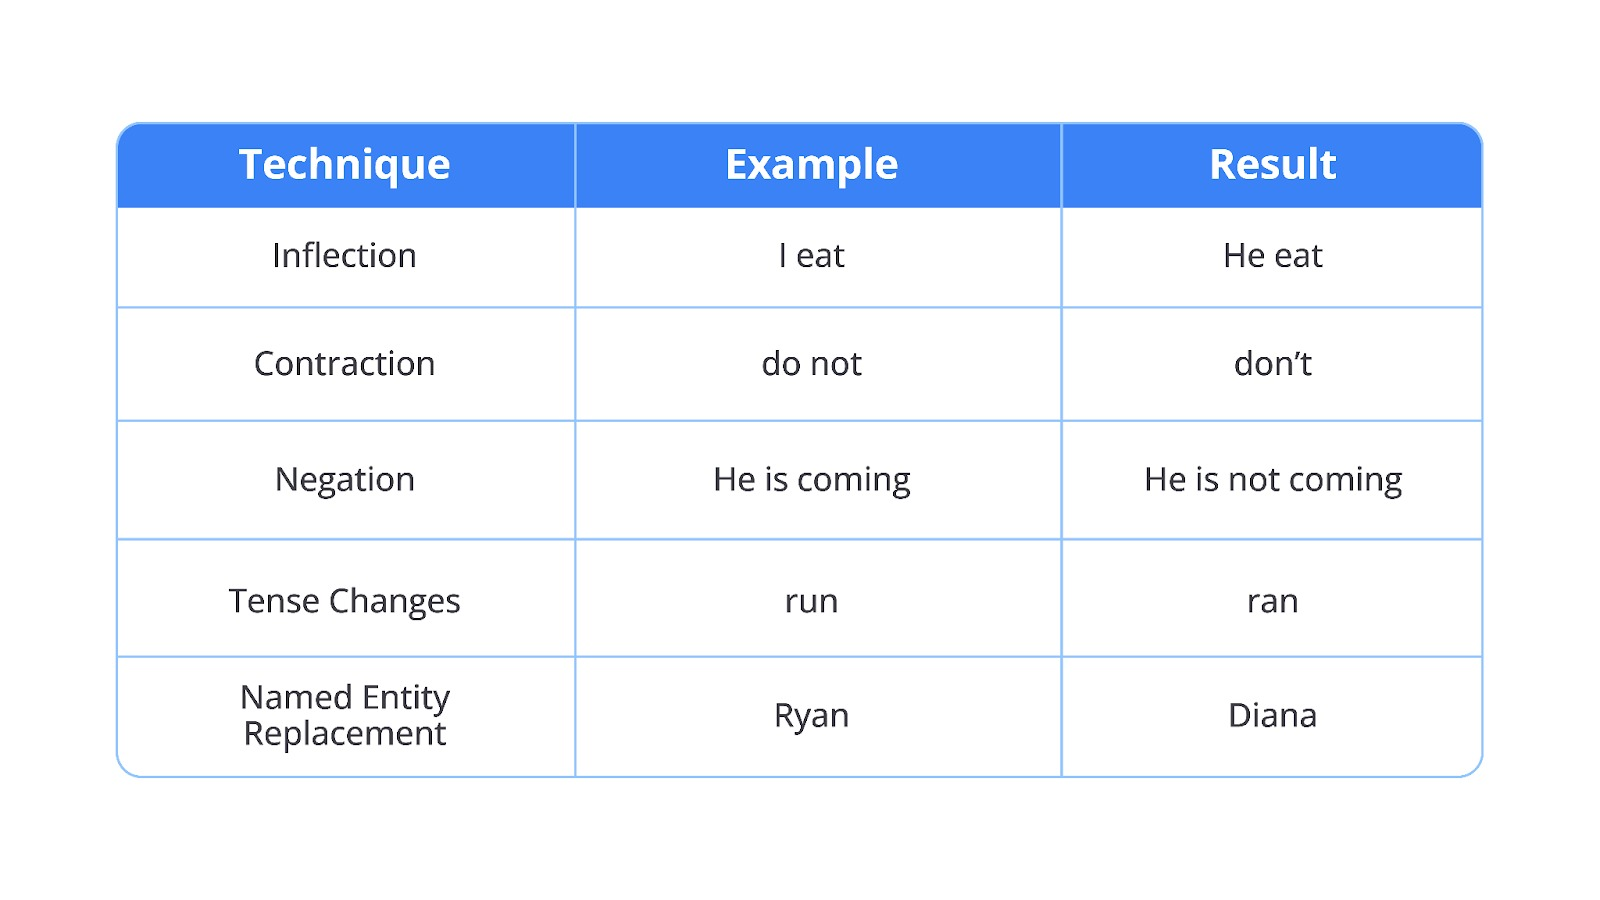

In [8]:
from textattack.augmentation import CheckListAugmenter

text = "TextAttack is a powerful library for NLP."

checklist_augmenter = CheckListAugmenter()

augmented_text = checklist_augmenter.augment(text)

print(f"Original Text: {text}")
print(f"Augmented Text: {augmented_text}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


pytorch_model.bin:   0%|          | 0.00/419M [00:00<?, ?B/s]

2026-04-28 07:21:19,418 SequenceTagger predicts: Dictionary with 20 tags: <unk>, O, S-ORG, S-MISC, B-PER, E-PER, S-LOC, B-ORG, E-ORG, I-PER, S-PER, B-MISC, I-MISC, E-MISC, I-ORG, B-LOC, E-LOC, I-LOC, <START>, <STOP>
Original Text: TextAttack is a powerful library for NLP.
Augmented Text: ['TextAttack is a powerful library for NLP.']


**CLARE Augmenter**

In [ ]:
from textattack.augmentation import CLAREAugmenter

# Sample text
text = "TextAttack is a powerful library for NLP."

# Initialize the CLAREAugmenter
CLARE_augmenter = CLAREAugmenter()

# Apply CheckList transformations
augmented_text = CLARE_augmenter.augment(text)

# Print the results
print(f"Original Text: {text}")
print(f"Augmented Text: {augmented_text}")

In [ ]:
# Sample text
text = "Ryan sangat suka belajar di Dicoding bersama temannya"

# Initialize the CLAREAugmenter with Indonesian Focused Model
CLARE_augmenter = CLAREAugmenter(model='cahya/roberta-base-indonesian-522M', tokenizer='cahya/roberta-base-indonesian-522M')

# Apply CheckList transformations
augmented_text = CLARE_augmenter.augment(text)

# Print the results
print(f"Original Text: {text}")
print(f"Augmented Text: {augmented_text}")